# Laboratorio 10: Procesamiento de Señales EKG

**Curso:** Introducción a Señales  
**Grupo:** 6  
**Fecha:** 25 de Noviembre, 2025  

## Objetivo
El objetivo de este laboratorio es cargar una base de datos de señales EKG reales, seleccionar una patología específica (Clase: **Trigeminy**) y aplicar algoritmos de procesamiento digital para detectar y segmentar las ondas principales del ciclo cardíaco: **Onda P, Complejo QRS y Onda T**.

## 1. Importación de Librerías
Se utilizarán las siguientes librerías:
*   `pickle`: Para deserializar y cargar el dataset.
*   `numpy`: Para manejo de matrices y vectores numéricos.
*   `matplotlib`: Para la visualización de las señales.
*   `neurokit2`: Librería especializada en el procesamiento de señales fisiológicas (detección de picos y delineación).

In [ ]:
# Instalación de librerías necesarias 
import pickle
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# Configuración de gráficos
plt.rcParams['figure.figsize'] = [15, 5]
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga de la Base de Datos
Se procede a cargar el archivo `dataset_ekg.pkl`. Este archivo contiene un diccionario donde las llaves son los tipos de arritmias/ritmos y los valores son matrices con las señales crudas.

In [ ]:
# Ruta del archivo 
file_path = r"ECG_DATASET/dataset_ekg.pkl" 

try:
    with open(file_path, 'rb') as f:
        dataset = pickle.load(f)
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print(f"Error: No se encuentra el archivo en la ruta: {file_path}")
    print("Por favor verifica la ruta del archivo .pkl")

Dataset cargado exitosamente.


## 3. Exploración de Clases Disponibles
Visualizamos las llaves del diccionario para confirmar las patologías disponibles en el dataset.

In [3]:
# Listar las claves (tipos de señales)
print("Clases disponibles en el dataset:")
print(list(dataset.keys()))

Clases disponibles en el dataset:
['NSR', 'VT', 'IVR', 'VFL', 'Fusion', 'LBBBB', 'RBBBB', 'SDHB', 'PR', 'APB', 'AFL', 'AFIB', 'SVTA', 'WPW', 'PVC', 'Bigeminy', 'Trigeminy']


## 4. Selección de la Señal de Interés
Para este laboratorio, se ha seleccionado la clase **'Trigeminy'** (Trigeminismo).
Esta arritmia se caracteriza por un patrón donde dos latidos normales son seguidos por un latido ectópico (irregular).

Se seleccionará la **Fila 0** de esta clase para el análisis.
**Frecuencia de muestreo (fs):** 360 Hz (Estándar para base de datos MIT-BIH).

Señal extraída: Clase Trigeminy, Fila 0
Duración: 10.0 segundos (3600 muestras)


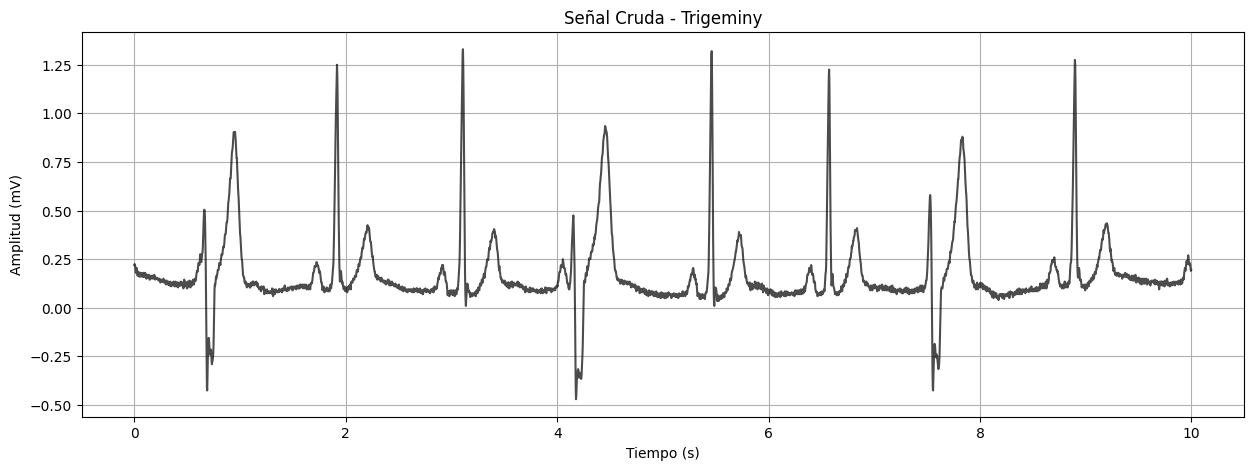

In [4]:
# Configuración de parámetros
CLASE_SELECCIONADA = "Trigeminy"
FILA = 0
FS = 360  # Frecuencia de muestreo típica de estos datasets

# Extracción de la señal
try:
    # El dataset es un diccionario de arrays, accedemos a la clase y luego a la fila
    raw_signal = dataset[CLASE_SELECCIONADA][FILA]
    
    # Crear vector de tiempo
    time = np.arange(len(raw_signal)) / FS
    
    print(f"Señal extraída: Clase {CLASE_SELECCIONADA}, Fila {FILA}")
    print(f"Duración: {len(raw_signal)/FS} segundos ({len(raw_signal)} muestras)")
except KeyError:
    print("Error: La clase seleccionada no existe en el diccionario.")

# Visualización de la señal cruda
plt.figure()
plt.plot(time, raw_signal, color='black', alpha=0.7)
plt.title(f"Señal Cruda - {CLASE_SELECCIONADA}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.grid(True)
plt.show()

## 5. Preprocesamiento
Las señales EKG reales suelen tener ruido de línea base o interferencia eléctrica. Utilizamos un filtro de limpieza provisto por `neurokit2` para mejorar la calidad de la detección.

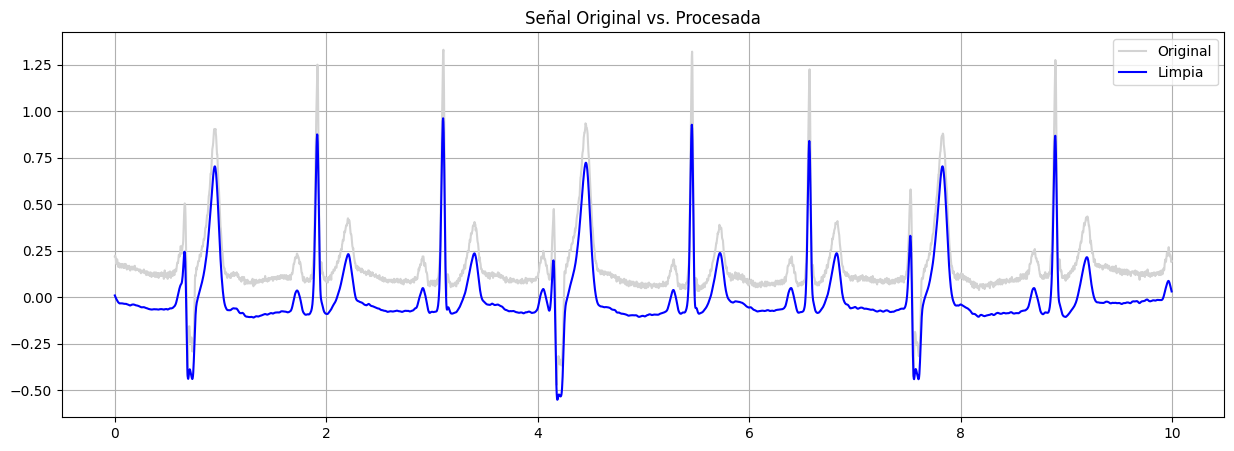

In [5]:
# Limpieza de la señal usando el método de Neurokit
ecg_cleaned = nk.ecg_clean(raw_signal, sampling_rate=FS, method="neurokit")

# Comparación visual
plt.figure()
plt.plot(time, raw_signal, color='lightgray', label='Original')
plt.plot(time, ecg_cleaned, color='blue', label='Limpia')
plt.title("Señal Original vs. Procesada")
plt.legend()
plt.grid(True)
plt.show()

# 6. Detección de Complejos QRS y Picos R

En esta sección implementamos un algoritmo personalizado para detectar los picos R (el punto más alto del latido cardíaco), que es fundamental para segmentar el ciclo cardiaco.

El algoritmo se basa en la técnica de **Pan-Tompkins** modificada e incluye:
1.  **Derivada:** Para detectar cambios bruscos (pendientes).
2.  **Cuadratura:** Para resaltar la energía de la señal.
3.  **Integración de Ventana Móvil (MWI):** Para suavizar y acumular energía.
4.  **Umbral Adaptativo:** Para decidir qué es un latido y qué es ruido.

In [18]:
from scipy.signal import butter, filtfilt, find_peaks
def moving_average(x, w):
    w = max(1, int(w))
    c = np.ones(w) / w
    return np.convolve(x, c, mode='same')


def _refine_peak(ecg, idx, half_win):
    """Refine approximate peak to the max of the raw ECG in ±half_win."""
    i0 = max(0, idx-half_win); i1 = min(len(ecg), idx+half_win+1)
    if i1-i0 <= 1: 
        return idx
    return i0 + np.argmax(ecg[i0:i1])

In [19]:
def detect_qrs_rpeaks(ecg, fs):
    """
    Returns r_peaks (sample indices), qrs_on (onsets), qrs_off (offsets).
    Method: bandpass(5–15 Hz) → derivative → square → MWI(150 ms) → adaptive threshold.
    """
    # Emphasize QRS bandwidth
    #qrs_bp = bandpass(ecg, fs, low=5.0, high=15.0, order=3)

    # PT-style preprocessing
    #der = np.append(np.diff(qrs_bp), 0)                    # derivative
    der = np.append(np.diff(ecg), 0)                    # derivative
    sq = der**2                                            # nonlinearity
    mwi = moving_average(sq, int(0.150*fs))                # ~150 ms integration

    # Adaptive threshold based on robust stats
    thr = np.median(mwi) + 1.5*np.median(np.abs(mwi - np.median(mwi)))  # median + 1.5*MAD

    # Refractory period ~200 ms to avoid double detections
    min_dist = int(0.2 * fs)
    pk_idx, _ = find_peaks(mwi, height=thr, distance=min_dist)

    # Refine each detection to true R on band-limited ECG (steeper & higher than raw)
    #r_peaks = np.array([_refine_peak(qrs_bp, p, half_win=int(0.05*fs)) for p in pk_idx], dtype=int)
    r_peaks = np.array([_refine_peak(ecg, p, half_win=int(0.05*fs)) for p in pk_idx], dtype=int)

    # QRS onset/offset from energy curve around each R
    qrs_on = []
    qrs_off = []
    half = int(0.12 * fs)  # ±120 ms search
    for r in r_peaks:
        i0 = max(0, r - half); i1 = min(len(mwi), r + half)
        seg = mwi[i0:i1]
        # define a local, conservative threshold
        loc_thr = np.median(seg)
        # onset: last index from r backwards where energy falls below local threshold
        on = i0 + np.where(seg[:(r-i0)][::-1] < loc_thr)[0]
        on = r - on[0] if len(on) else i0
        # offset: first index after r where energy falls below local threshold
        off = i0 + (np.where(seg[(r-i0):] < loc_thr)[0][0] if np.any(seg[(r-i0):] < loc_thr) else (i1 - i0 - 1))
        qrs_on.append(int(on))
        qrs_off.append(int(off))
    return r_peaks, np.array(qrs_on), np.array(qrs_off)
    

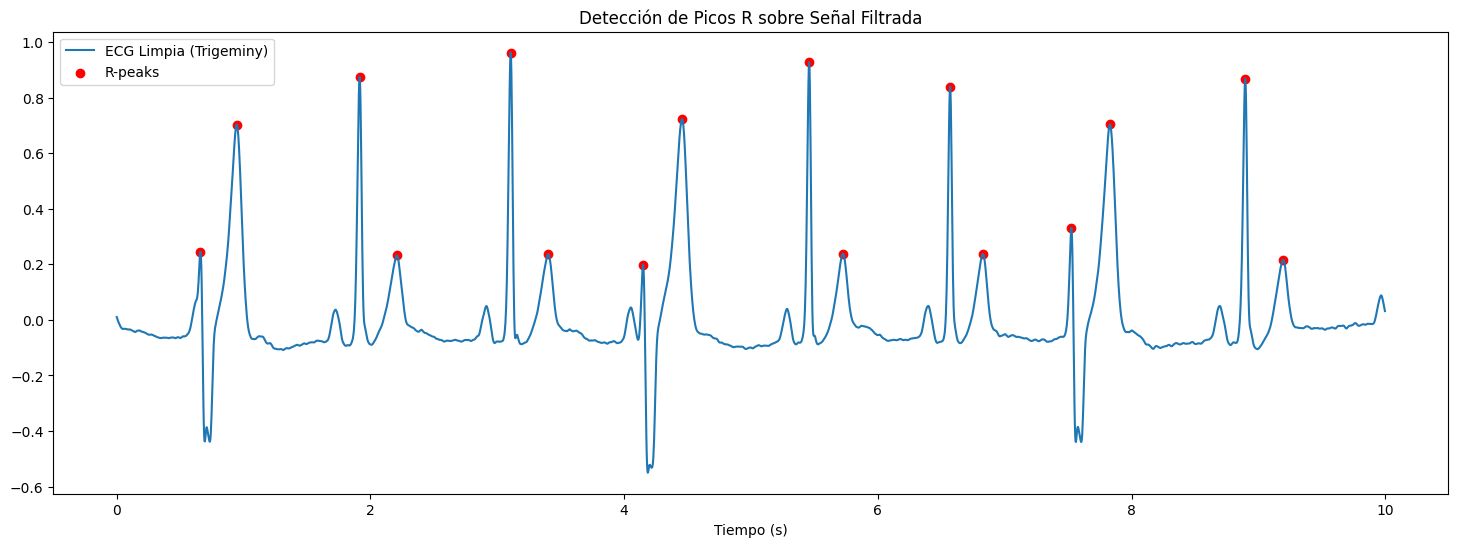

In [20]:
r_peaks_clean, _, _ = detect_qrs_rpeaks(ecg_cleaned, FS)  # Usamos ecg_cleaned en vez de ecg_signal

# 2. Graficar
plt.figure(figsize=(18, 6))
plt.plot(time, ecg_cleaned, label='ECG Limpia (Trigeminy)')
plt.scatter(time[r_peaks_clean], ecg_cleaned[r_peaks_clean], color='red', label='R-peaks')

plt.title('Detección de Picos R sobre Señal Filtrada')
plt.xlabel('Tiempo (s)')
plt.legend()
plt.show()

In [21]:
from scipy.signal import butter, filtfilt, find_peaks, hilbert, peak_widths
import pywt
def detect_pwaves_only(ecg, fs, r_peaks=None):
    """
    Detect P-wave peaks without requiring R-peak anchors.
    Optional: supply r_peaks to reject events too close to QRS.
    Returns:
      p_idx: sample indices of P-wave peaks
      p_env: envelope used for detection (for plotting/QA)
    """
    x_bp, x_p, env = enhance_p_band(ecg, fs)

    # Adaptive threshold on the envelope
    thr = robust_thr(env, k=2.0)

    # Physiologic constraints
    min_rr_like = int(0.20*fs)     # refractory ~200 ms (avoid double P)
    p_idx, props = find_peaks(env, height=thr, distance=min_rr_like, prominence=np.std(env)*0.2)

    # Width filter: expect ~60–120 ms (allow 40–160 ms to be tolerant)
    if len(p_idx) > 0:
        w_res = peak_widths(env, p_idx, rel_height=0.5)
        widths = w_res[0] / fs  # in seconds
        keep = (widths >= 0.040) & (widths <= 0.160)
        p_idx = p_idx[keep]

    # Optional: reject candidates too close to QRS (if R provided)
    if r_peaks is not None and len(p_idx) > 0 and len(r_peaks) > 0:
        mask = np.ones_like(p_idx, dtype=bool)
        for i, p in enumerate(p_idx):
            # If within ±60 ms of an R, discard (likely part of QRS/T)
            if np.any(np.abs(r_peaks - p) <= int(0.06*fs)):
                mask[i] = False
        p_idx = p_idx[mask]

    return p_idx.astype(int), env, x_bp, x_p

In [ ]:
def butter_bandpass(low, high, fs, order=3):
    nyq = 0.5*fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return b, a

def bandpass(x, fs, low=0.5, high=15.0, order=3):
    b, a = butter_bandpass(low, high, fs, order)
    return filtfilt(b, a, x)

def robust_thr(x, k=2.2):
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    return med + k*mad

def enhance_p_band(ecg, fs):
    """
    Bandpass (0.5–15 Hz) to suppress drift & HF noise, then
    wavelet detail reconstruction in ~4–12 Hz and amplitude envelope.
    """
    x = bandpass(ecg, fs, 0.5, 15.0, order=3)

    # Choose a wavelet level whose pseudo-band covers ~4–12 Hz.
    # Heuristic: level ≈ round(log2(fs/24)) bounded to [2,5]
    level = int(np.clip(np.rint(np.log2(fs/24.0)), 2, 5))
    coeffs = pywt.wavedec(x, 'db6', level=level)

    # Keep only one detail level near the P band
    keep = [np.zeros_like(c) for c in coeffs]
    target_detail = len(coeffs) - level  # detail index to keep
    keep[target_detail] = coeffs[target_detail]
    x_p = pywt.waverec(keep, 'db6')
    x_p = x_p[:len(x)]

    # Envelope of the enhanced signal (smooth energy)
    env = np.abs(hilbert(x_p))
    # Light smoothing (~30 ms) to stabilize envelope
    w = max(1, int(0.03*fs))
    env = np.convolve(env, np.ones(w)/w, mode='same')
    return x, x_p, env

# 7. Detección de Onda P (Método 1: Manual)

La onda P representa la despolarización auricular y es a menudo la más difícil de detectar debido a su baja amplitud y susceptibilidad al ruido.

En esta sección implementamos un **algoritmo manual personalizado** que combina técnicas de procesamiento digital avanzado para aislar esta onda específica.

**Metodología del Algoritmo:**
1.  **Filtrado Paso-Banda (0.5 - 15 Hz):** Para eliminar el ruido de alta frecuencia y la línea base, conservando las frecuencias donde reside la energía de la onda P.
2.  **Transformada Wavelet (db6):** Utilizamos la descomposición Wavelet para realzar específicamente los componentes de la señal entre 4 Hz y 12 Hz.
3.  **Envolvente de Hilbert:** Calculamos la envolvente analítica de la señal realzada para obtener una curva de "energía" suave.
4.  **Lógica de Decisión:** Aplicamos umbrales adaptativos y restricciones fisiológicas (duración entre 40ms y 160ms) para diferenciar una onda P real del ruido.

Análisis de señal completa: Se detectaron 9 ondas P.


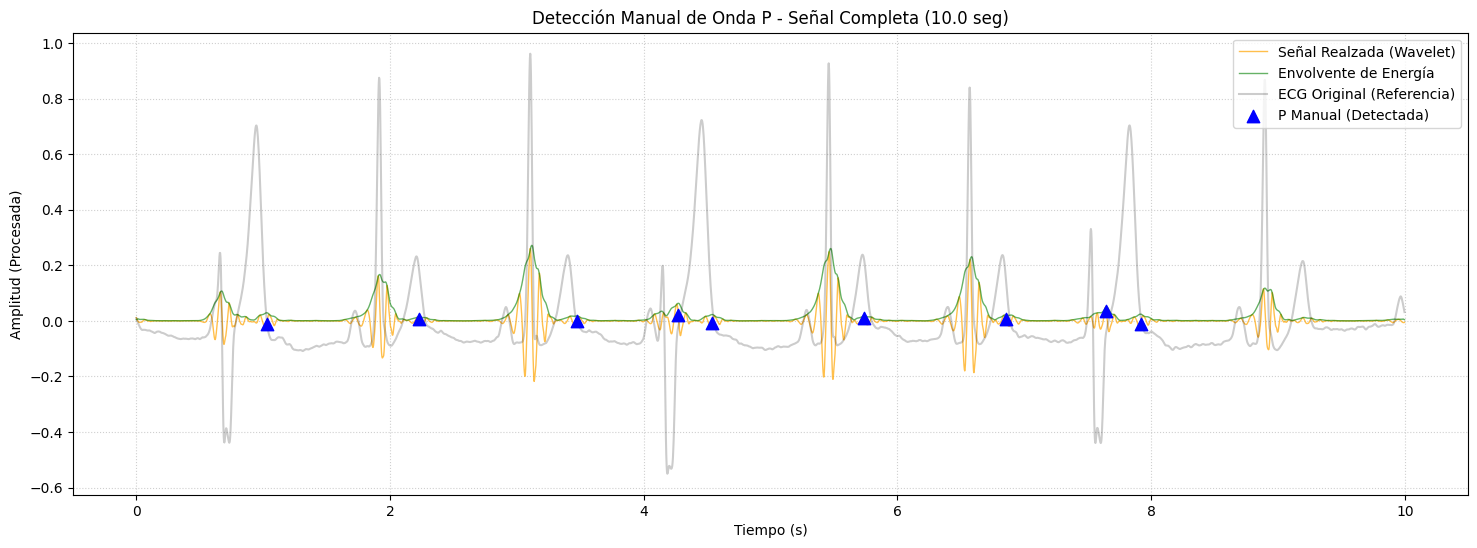

In [ ]:
# 1. Obtener referencias de picos R (necesario para ayudar al algoritmo manual)
_, rpeaks_info = nk.ecg_peaks(ecg_cleaned, sampling_rate=FS)
r_peaks_real = rpeaks_info['ECG_R_Peaks']

# 2. Ejecutar el detector manual
p_idx_manual, p_env_manual, x_bp_manual, x_p_manual = detect_pwaves_only(ecg_cleaned, FS, r_peaks=r_peaks_real)

print(f"Análisis de señal completa: Se detectaron {len(p_idx_manual)} ondas P.")

# 3. Visualización de la señal
plt.figure(figsize=(18, 6))

plt.plot(time, x_p_manual, color='orange', alpha=0.7, label='Señal Realzada (Wavelet)', linewidth=1)
plt.plot(time, p_env_manual, color='green', alpha=0.6, label='Envolvente de Energía', linewidth=1)

# Graficamos la señal ECG original de fondo (en gris/negro transparente) para comparar
plt.plot(time, ecg_cleaned, color='black', alpha=0.2, label='ECG Original (Referencia)')

# Graficamos los marcadores (Triángulos Azules)
# Usamos todos los índices detectados
plt.scatter(time[p_idx_manual], x_p_manual[p_idx_manual], color='blue', s=80, marker='^', label='P Manual (Detectada)', zorder=5)

plt.title(f"Detección Manual de Onda P - Señal Completa ({len(time)/FS:.1f} seg)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (Procesada)")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 8. Detección y Segmentación Completa (Método 2: Neurokit2)

En esta sección utilizamos la librería especializada `Neurokit2` para realizar un análisis integral de la señal EKG de forma automática.

A diferencia del método manual, la función `ecg_process` de Neurokit2 implementa internamente algoritmos validados y robustos para:
1.  **Detección de Picos R (QRS):** Utilizando algoritmos basados en la derivada y la energía (similares a Pan-Tompkins).
2.  **Delineación de Ondas:** Localiza con precisión los picos y límites de las ondas **P** y **T**, tomando como referencia la ubicación de los complejos QRS detectados.

Este método es el estándar para procesar grandes volúmenes de datos o señales con morfologías complejas como las arritmias.

In [ ]:
# Extraemos los índices de interés para reportar
r_peaks = info['ECG_R_Peaks']
p_peaks = np.array(info['ECG_P_Peaks'])
t_peaks = np.array(info['ECG_T_Peaks'])

p_peaks = p_peaks[~np.isnan(p_peaks)].astype(int)
t_peaks = t_peaks[~np.isnan(t_peaks)].astype(int)

print(f"Número de complejos QRS detectados: {len(r_peaks)}")
print(f"Número de ondas P detectadas: {len(p_peaks)}")
print(f"Número de ondas T detectadas: {len(t_peaks)}")

Número de complejos QRS detectados: 10
Número de ondas P detectadas: 9
Número de ondas T detectadas: 8


# 9. Visualización de Resultados con Anotaciones

A continuación, se grafica la señal de **Trigeminia** limpia con marcadores visuales para cada componente detectado por el algoritmo automático:

*   **<span style="color:red">Rojo (X):</span>** Picos R (Complejo QRS - Despolarización Ventricular)
*   **<span style="color:green">Verde (^):</span>** Ondas P (Despolarización Auricular)
*   **<span style="color:blue">Azul (o):</span>** Ondas T (Repolarización Ventricular)

Esta visualización permite validar si el algoritmo logró identificar correctamente la estructura del latido cardiaco a pesar de la arritmia.

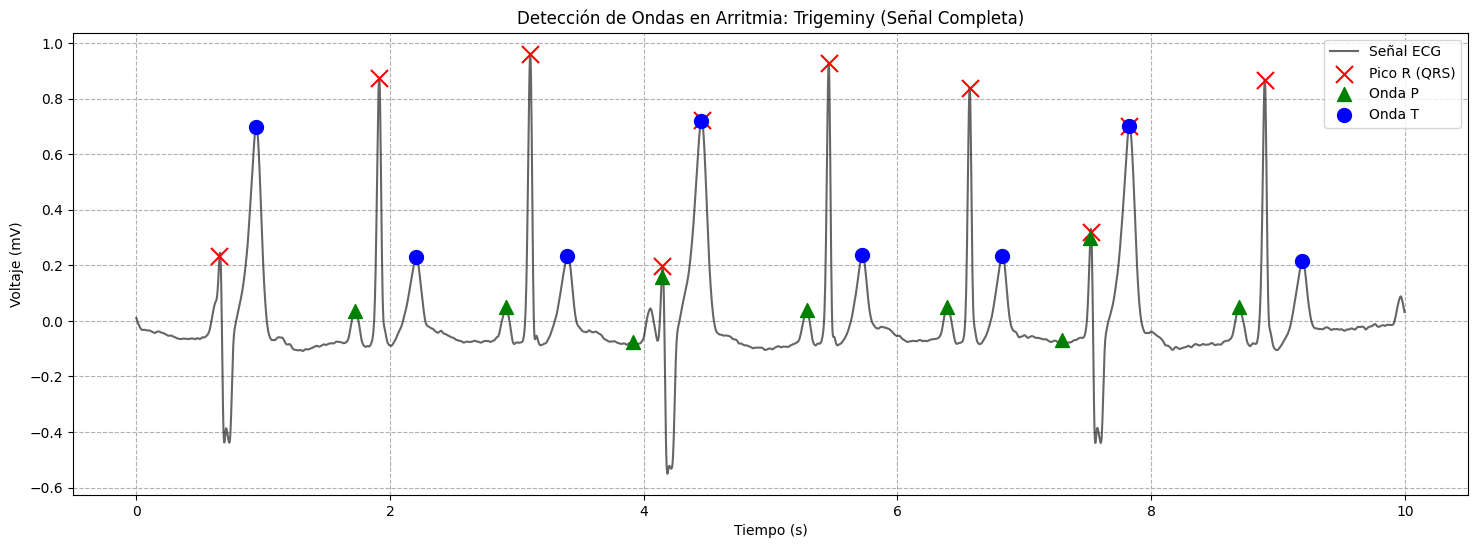

In [ ]:
plt.figure(figsize=(18, 6))

# 1. Plotear señal limpia
plt.plot(time, ecg_cleaned, color='black', alpha=0.6, label='Señal ECG')

# 2. Plotear Picos R (QRS)
plt.scatter(time[r_peaks], ecg_cleaned[r_peaks], color='red', s=150, marker='x', label='Pico R (QRS)', zorder=3)

# 3. Plotear Ondas P
plt.scatter(time[p_peaks], ecg_cleaned[p_peaks], color='green', s=100, marker='^', label='Onda P', zorder=3)

# 4. Plotear Ondas T
plt.scatter(time[t_peaks], ecg_cleaned[t_peaks], color='blue', s=100, marker='o', label='Onda T', zorder=3)

plt.title(f"Detección de Ondas en Arritmia: {CLASE_SELECCIONADA} (Señal Completa)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (mV)")
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--')

plt.show()

# 10. Análisis Comparativo: Trigeminismo vs. Ritmo Sinusal Normal (NSR)

Para comprender mejor las alteraciones electrofisiológicas de la arritmia seleccionada, realizamos una comparación directa con una señal de referencia sana (**NSR** - *Normal Sinus Rhythm*).

**Metodología de Comparación:**
1.  **Selección:** Se extrae una señal aleatoria de la clase `NSR` del mismo dataset.
2.  **Procesamiento:** Se aplica la misma cadena de limpieza y detección de ondas P utilizada anteriormente.
3.  **Visualización:** Se generan tres gráficos sincronizados:
    *   **Panel Superior:** Señal de **Trigeminismo** (arritmia), mostrando su patrón irregular de latidos agrupados.
    *   **Panel Central:** Señal **NSR** (normal), mostrando un ritmo regular y constante.
    *   **Panel Inferior:** **Superposición** de ambas señales. La señal patológica se muestra en gris tenue de fondo para resaltar cómo la señal normal (azul) difiere en frecuencia y morfología, evidenciando los latidos prematuros y las pausas compensatorias típicas de la arritmia.

Señal de comparación extraída: Clase NSR


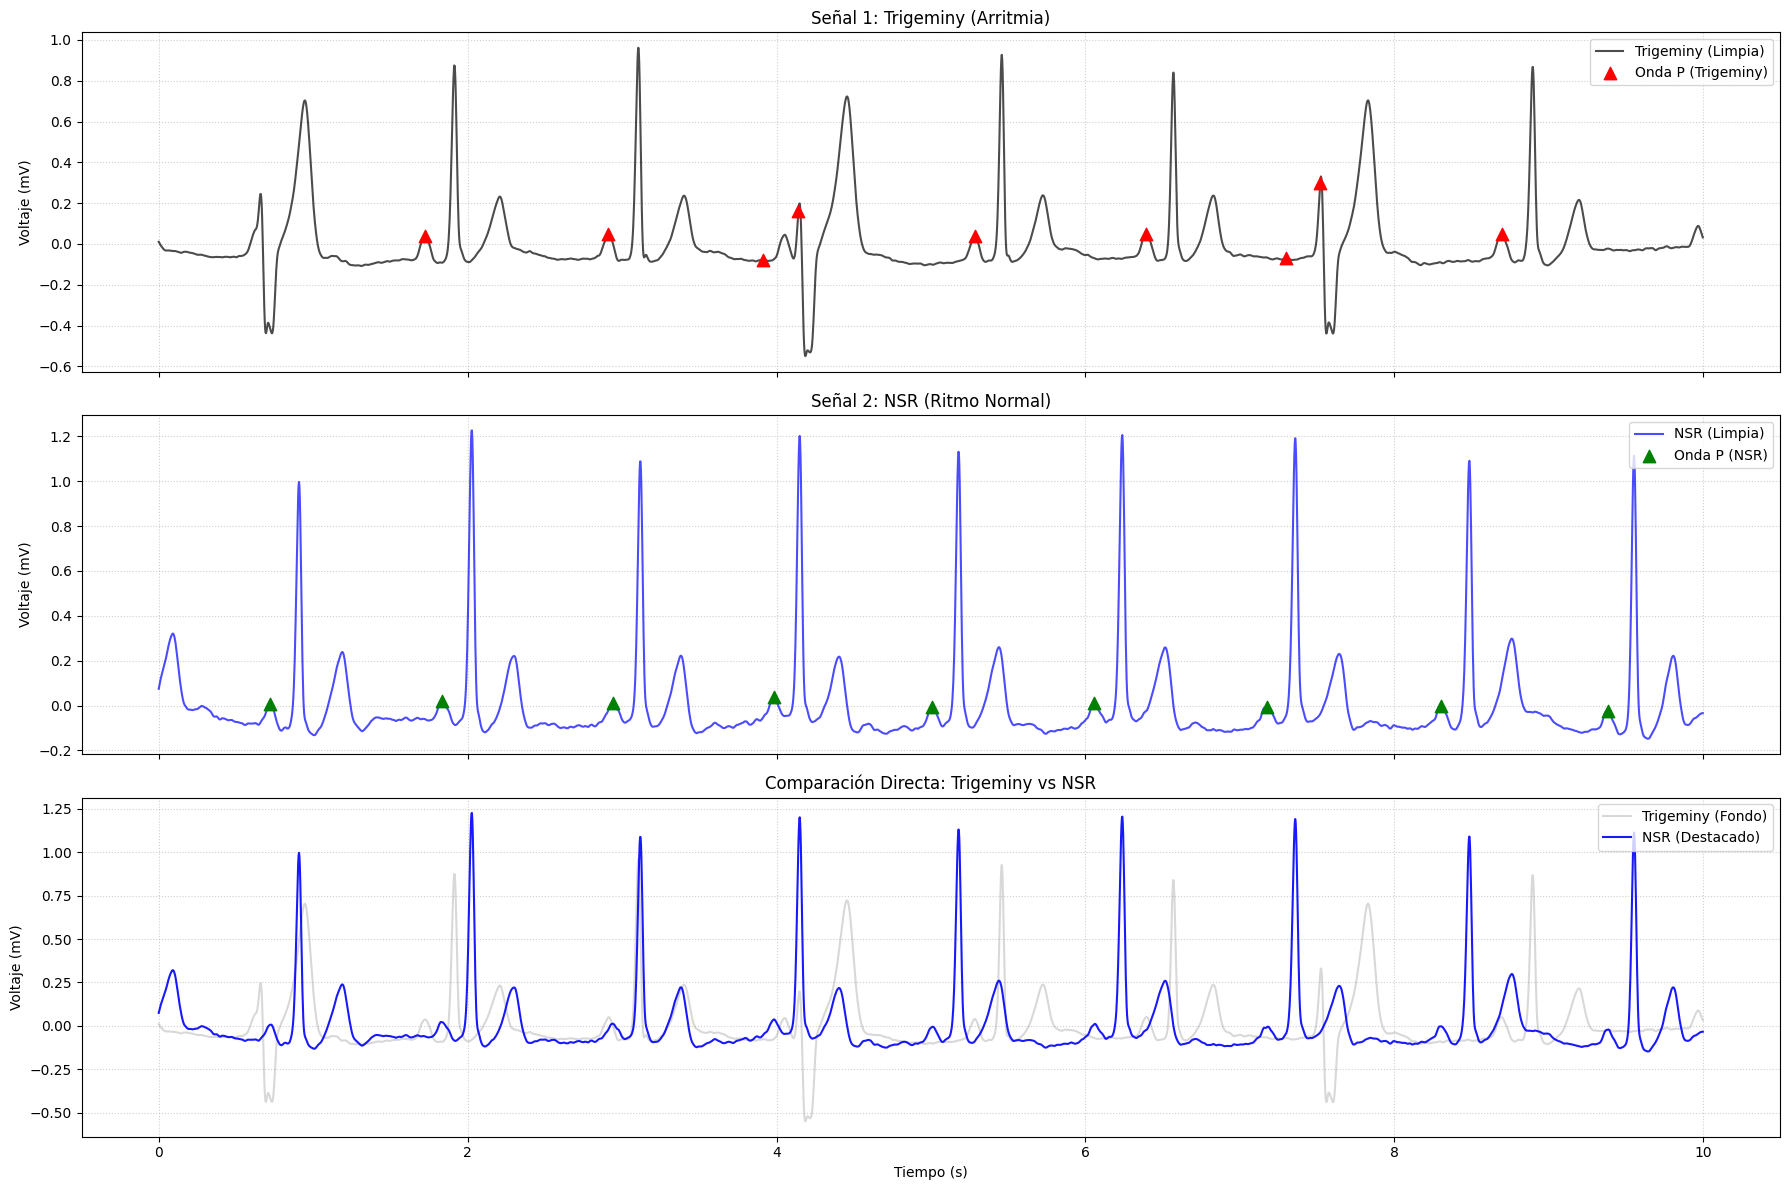

In [ ]:
# 1. Selección de la segunda señal (NSR - Ritmo Sinusal Normal)
CLASE_COMPARACION = "NSR"
try:
    raw_signal_2 = dataset[CLASE_COMPARACION][0] # Fila 0 de la nueva clase
    ecg_cleaned_2 = nk.ecg_clean(raw_signal_2, sampling_rate=FS, method="neurokit")
    
    # Procesamiento para detección de picos en la segunda señal
    signals_2, info_2 = nk.ecg_process(ecg_cleaned_2, sampling_rate=FS)

    # --- CORRECCIÓN AQUÍ ---
    # Convertimos a np.array ANTES de filtrar
    p_peaks_2 = np.array(info_2['ECG_P_Peaks'])
    
    # Ahora sí podemos filtrar
    p_peaks_2 = p_peaks_2[~np.isnan(p_peaks_2)].astype(int)
    
    print(f"Señal de comparación extraída: Clase {CLASE_COMPARACION}")
except KeyError:
    print(f"Error: La clase {CLASE_COMPARACION} no existe.")


# 2. Configuración del gráfico comparativo (3 subplots)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Subplot 1: Señal de Trigeminy
ax1.plot(time, ecg_cleaned, color='black', alpha=0.7, label='Trigeminy (Limpia)')
ax1.scatter(time[p_peaks], ecg_cleaned[p_peaks], color='red', marker='^', s=80, label='Onda P (Trigeminy)', zorder=5)
ax1.set_title(f"Señal 1: {CLASE_SELECCIONADA} (Arritmia)")
ax1.set_ylabel("Voltaje (mV)")
ax1.legend(loc="upper right")
ax1.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Señal de NSR
ax2.plot(time, ecg_cleaned_2, color='blue', alpha=0.7, label=f'{CLASE_COMPARACION} (Limpia)')
ax2.scatter(time[p_peaks_2], ecg_cleaned_2[p_peaks_2], color='green', marker='^', s=80, label=f'Onda P ({CLASE_COMPARACION})', zorder=5)
ax2.set_title(f"Señal 2: {CLASE_COMPARACION} (Ritmo Normal)")
ax2.set_ylabel("Voltaje (mV)")
ax2.legend(loc="upper right")
ax2.grid(True, linestyle=':', alpha=0.6)

# Subplot 3: Superposición
ax3.plot(time, ecg_cleaned, color='gray', alpha=0.3, linewidth=1.5, label='Trigeminy (Fondo)')
ax3.plot(time, ecg_cleaned_2, color='blue', alpha=0.9, linewidth=1.5, label=f'{CLASE_COMPARACION} (Destacado)')
ax3.set_title(f"Comparación Directa: {CLASE_SELECCIONADA} vs {CLASE_COMPARACION}")
ax3.set_xlabel("Tiempo (s)")
ax3.set_ylabel("Voltaje (mV)")
ax3.legend(loc="upper right")
ax3.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 11. Validación del Algoritmo Automático (NeuroKit2)

Finalmente, hemos utilizado la librería **NeuroKit2** para procesar y comparar dos escenarios clínicos opuestos: una arritmia compleja (**Trigeminismo**) y un ritmo cardiaco sano (**NSR**).

**Observaciones del Análisis:**
*   **En Ritmo Normal (NSR):** El algoritmo detectó de forma consistente una onda P precediendo a cada complejo QRS a intervalos regulares, validando su precisión en condiciones fisiológicas estándar.
*   **En Arritmia (Trigeminismo):** A pesar de la irregularidad temporal y la morfología alterada de los latidos ectópicos, NeuroKit2 logró segmentar los ciclos correctamente.

La comparación visual realizada anteriormente demuestra que el algoritmo automático es **robusto**, adaptándose tanto a ritmos estables como a alteraciones bruscas en la frecuencia cardiaca sin requerir reajustes manuales de parámetros.

Análisis de NSR completado.


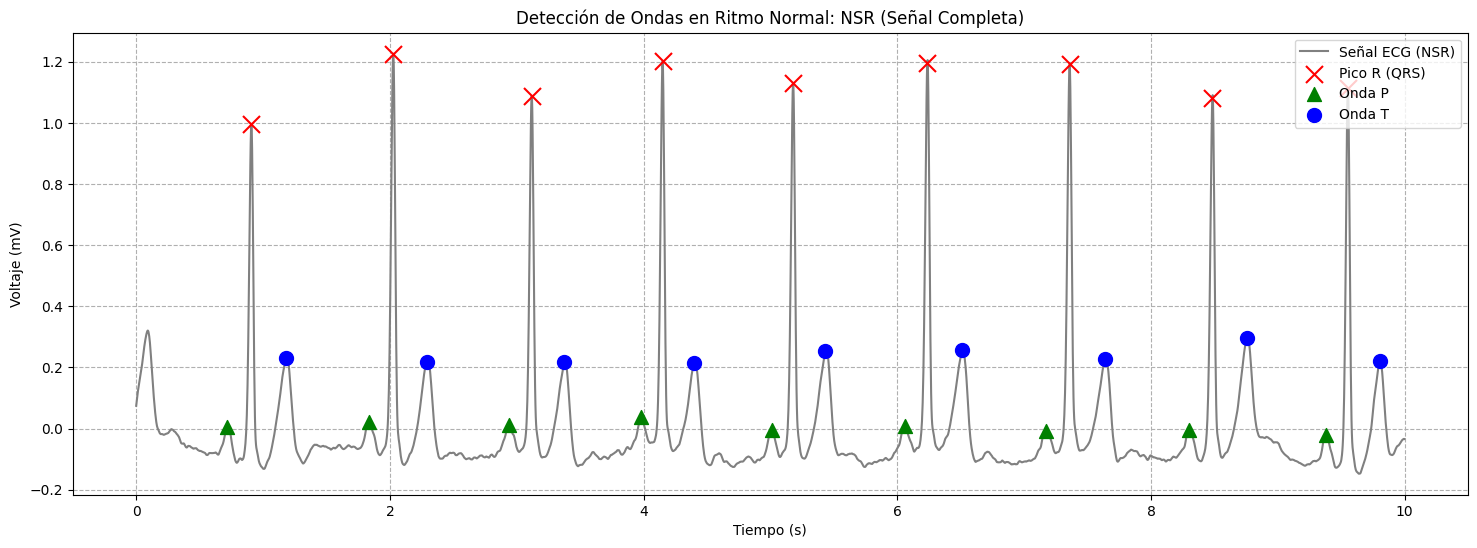

In [ ]:
# 1. Selección y Preprocesamiento de NSR
CLASE_NSR = "NSR"
try:
    # Seleccionamos la primera señal (fila 0) de la clase NSR
    raw_nsr = dataset[CLASE_NSR][0]
    
    # Limpiamos la señal
    ecg_nsr_clean = nk.ecg_clean(raw_nsr, sampling_rate=FS, method="neurokit")
    
    # Procesamos para detectar todas las ondas (P, QRS, T)
    _, info_nsr = nk.ecg_process(ecg_nsr_clean, sampling_rate=FS)
    
    # Extraemos y limpiamos los índices de los picos
    r_peaks_n = info_nsr['ECG_R_Peaks']
    p_peaks_n = info_nsr['ECG_P_Peaks']
    t_peaks_n = info_nsr['ECG_T_Peaks']
    
    # Convertimos a enteros y filtramos NaNs
    p_peaks_n = np.array(p_peaks_n)
    t_peaks_n = np.array(t_peaks_n)
    p_peaks_n = p_peaks_n[~np.isnan(p_peaks_n)].astype(int)
    t_peaks_n = t_peaks_n[~np.isnan(t_peaks_n)].astype(int)
    
    print(f"Análisis de {CLASE_NSR} completado.")

    # 2. Visualización de la Señal Completa
    plt.figure(figsize=(18, 6))
    
    # Plotear señal limpia
    plt.plot(time, ecg_nsr_clean, color='gray', linewidth=1.5, label='Señal ECG (NSR)')
    
    # Plotear Picos R (QRS)
    plt.scatter(time[r_peaks_n], ecg_nsr_clean[r_peaks_n], color='red', s=150, marker='x', label='Pico R (QRS)', zorder=3)
    
    # Plotear Ondas P
    plt.scatter(time[p_peaks_n], ecg_nsr_clean[p_peaks_n], color='green', s=100, marker='^', label='Onda P', zorder=3)
    
    # Plotear Ondas T
    plt.scatter(time[t_peaks_n], ecg_nsr_clean[t_peaks_n], color='blue', s=100, marker='o', label='Onda T', zorder=3)
    
    # Decoración
    plt.title(f"Detección de Ondas en Ritmo Normal: {CLASE_NSR} (Señal Completa)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (mV)")
    plt.legend(loc='upper right')
    plt.grid(True, which='both', linestyle='--')
    
    plt.show()

except KeyError:
    print(f"Error: La clase {CLASE_NSR} no se encontró en el dataset.")